# Project : DSE-2 : Data Mining - I <br> Classification Model using Naive Bayes Algorithm
### By: Dhirendra Kumar Patel, Nikhil Kumar Sahu <br> (Bsc Hons. Computer Science Sem-4)
<hr size="5">

# 1. Import Required Libraries

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, LeaveOneOut, cross_val_score
import category_encoders as ce
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# 2. Import DATASET

In [2]:
data = 'adult.data'
df = pd.read_csv(data, header=None, sep=', ', engine='python')

# 3. Exploratory Data Analysis

In [3]:
df.shape

(32561, 15)

In [4]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
df.tail()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [6]:
col_names = ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship',
             'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']
df.columns = col_names
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [8]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [9]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [10]:
for col in df.columns:
    print(col,'\n', df[col].unique(),'\n')

age 
 [39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87] 

workclass 
 ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked'] 

fnlwgt 
 [ 77516  83311 215646 ...  34066  84661 257302] 

education 
 ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th'] 

education_num 
 [13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8] 

marital_status 
 ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed'] 

occupation 
 ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-

# 4. Preprocessing : Handle Irregular Values

In [11]:
print("Irregularities in Data Set:")
for col in df.columns:
    if '?' in df[col].unique():
        print(col,'\t',(df[col]=='?').sum(),'\t=',(df[col]=='?').sum()*100/df.shape[0],'%')

Irregularities in Data Set:
workclass 	 1836 	= 5.638647461687294 %
occupation 	 1843 	= 5.660145572924664 %
native_country 	 583 	= 1.7904855501980896 %


## 4.1. Method 1 : Replaced '?' values with string 'Unknown'

In [12]:
cleaned1=df.replace('?', "Unknown")

## 4.2. Method 2 : Replaced '?' values with Random Subsampling (Proportion same as original)

In [13]:
cleaned2=df.replace('?', np.NaN)

In [14]:
cleaned2['workclass'].value_counts(normalize=True)

workclass
Private             0.738682
Self-emp-not-inc    0.082701
Local-gov           0.068120
State-gov           0.042246
Self-emp-inc        0.036322
Federal-gov         0.031245
Without-pay         0.000456
Never-worked        0.000228
Name: proportion, dtype: float64

In [15]:
cleaned2.value_counts(normalize=True).sum()

1.0000000000000002

In [16]:
proportions = {
    'workclass': cleaned2['workclass'].value_counts(normalize=True),
    'occupation': cleaned2['occupation'].value_counts(normalize=True),
    'native_country': cleaned2['native_country'].value_counts(normalize=True)
}

In [17]:
proportions

{'workclass': workclass
 Private             0.738682
 Self-emp-not-inc    0.082701
 Local-gov           0.068120
 State-gov           0.042246
 Self-emp-inc        0.036322
 Federal-gov         0.031245
 Without-pay         0.000456
 Never-worked        0.000228
 Name: proportion, dtype: float64,
 'occupation': occupation
 Prof-specialty       0.134774
 Craft-repair         0.133440
 Exec-managerial      0.132365
 Adm-clerical         0.122729
 Sales                0.118823
 Other-service        0.107266
 Machine-op-inspct    0.065174
 Transport-moving     0.051989
 Handlers-cleaners    0.044599
 Farming-fishing      0.032359
 Tech-support         0.030210
 Protective-serv      0.021128
 Priv-house-serv      0.004851
 Armed-Forces         0.000293
 Name: proportion, dtype: float64,
 'native_country': native_country
 United-States                 0.912190
 Mexico                        0.020108
 Philippines                   0.006192
 Germany                       0.004284
 Canada     

In [18]:
for col in ['workclass', 'occupation', 'native_country']:
    missing_indices = cleaned2[cleaned2[col].isnull()].index
    fill_values = np.random.choice(proportions[col].index, size=len(missing_indices), p=proportions[col].values)
    cleaned2.loc[missing_indices, col] = fill_values

In [19]:
comparison_df=pd.DataFrame({'Before':df['workclass'].value_counts(),
              'After':cleaned2['workclass'].value_counts()})
comparison_df.loc['Sum']=comparison_df.sum()
comparison_df

,Before,After
workclass,,
?,1836.0,NaN
Federal-gov,960.0,1025.0
Local-gov,2093.0,2206.0
Never-worked,7.0,7.0
Private,22696.0,24037.0
Self-emp-inc,1116.0,1188.0
Self-emp-not-inc,2541.0,2694.0
State-gov,1298.0,1389.0
Without-pay,14.0,15.0


## 4.3. Method 3 : Drop rows with any missing values

In [20]:
cleaned3=df.replace('?',np.NaN).dropna(how='any')

In [21]:
cleaned3.shape

(30162, 15)

# 5. Preprocessing : Declare Feature Vector and Target Variable

In [22]:
cleaned1.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [23]:
cleaned1.shape

(32561, 15)

In [24]:
X1=cleaned1.iloc[:,:-1]
X1.shape

(32561, 14)

In [25]:
y1=cleaned1.iloc[:,[-1]]
y1.shape

(32561, 1)

# 6. Preprocessing : Split Data into separate Training and Test Sets
## 6.1. HoldOut Method : Dataset is split into two sets, usually a training set and a test set. The model is trained on the training set and evaluated on the test set

In [26]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size = 0.3, random_state = 7)

## 6.2. K-fold Cross Validation : Dataset is divided into k folds. The model is trained on k-1 folds and tested on the remaining fold. This process is repeated k times, with each fold used once as the test set.

In [27]:
kfold_values = [5]

## 6.3. Stratified K-fold Cross Validation : Similar to k-fold cross-validation, but each fold has the same proportion of classes as the original dataset. (Useful for imbalanced datasets where one class is much more prevalent than others)

In [28]:
skf_values = [5]

# 7. Preprocessing : One Hot Encode the Categorical Values

In [29]:
X1_test.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
18329,39,Private,81487,Some-college,10,Divorced,Exec-managerial,Unmarried,White,Female,0,625,40,United-States
997,48,Federal-gov,33109,Bachelors,13,Divorced,Exec-managerial,Unmarried,White,Male,0,0,58,United-States
13225,22,Private,60331,Some-college,10,Married-civ-spouse,Other-service,Husband,White,Male,0,0,35,United-States
6837,23,State-gov,186634,12th,8,Never-married,Exec-managerial,Not-in-family,White,Male,0,0,40,United-States
29132,50,Self-emp-not-inc,334273,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,8,United-States


In [30]:
categorical= [col for col in X1_test.columns if X1_test[col].dtype=='object']
categorical

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country']

In [31]:
encoder = ce.OneHotEncoder(cols=categorical)

encoded_X1_train = encoder.fit_transform(X1_train)
encoded_X1_test = encoder.transform(X1_test)

In [32]:
encoded_X1_train.head(3)

,age,workclass_1,workclass_2,workclass_3,workclass_4,workclass_5,workclass_6,workclass_7,workclass_8,workclass_9,...,native_country_32,native_country_33,native_country_34,native_country_35,native_country_36,native_country_37,native_country_38,native_country_39,native_country_40,native_country_41
24027,86,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10781,58,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8676,27,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# 8. Preprocessing : Scaling Numerical Values

In [33]:
X1_test.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
18329,39,Private,81487,Some-college,10,Divorced,Exec-managerial,Unmarried,White,Female,0,625,40,United-States
997,48,Federal-gov,33109,Bachelors,13,Divorced,Exec-managerial,Unmarried,White,Male,0,0,58,United-States
13225,22,Private,60331,Some-college,10,Married-civ-spouse,Other-service,Husband,White,Male,0,0,35,United-States
6837,23,State-gov,186634,12th,8,Never-married,Exec-managerial,Not-in-family,White,Male,0,0,40,United-States
29132,50,Self-emp-not-inc,334273,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,8,United-States


In [34]:
numerical=[col for col in X1_test.columns if X1_test[col].dtype=='int64']
numerical

['age',
 'fnlwgt',
 'education_num',
 'capital_gain',
 'capital_loss',
 'hours_per_week']

## 8.0. Boxplot

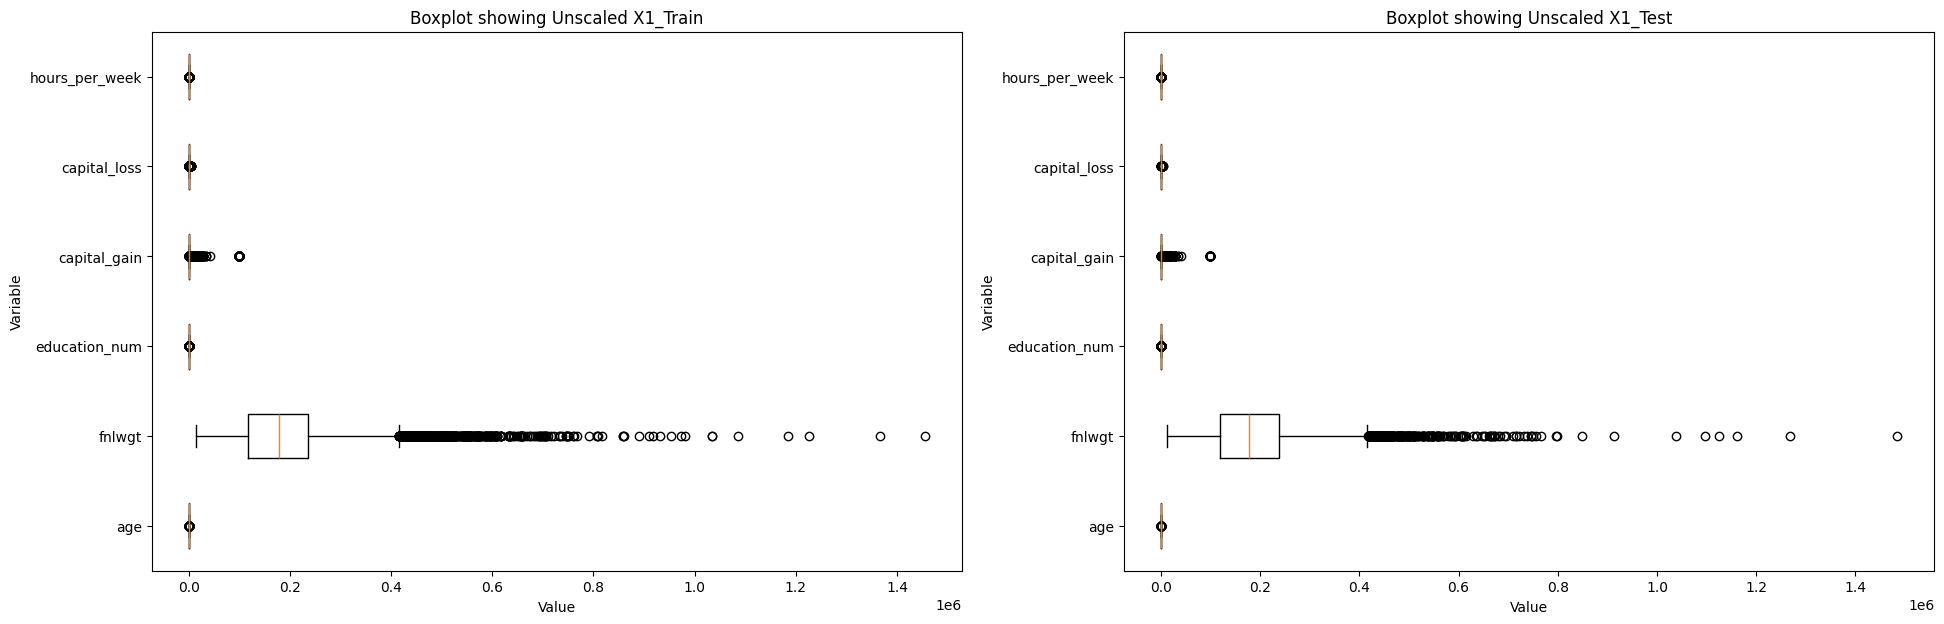

In [35]:
def box_plot(a1, a2,
             b1, b2):
    plt.figure(figsize=(23,7))

    plt.subplot(1,2,1)
    plt.boxplot(a1[numerical], labels=numerical, vert=False)
    plt.xlabel("Value")
    plt.ylabel("Variable")
    plt.title("Boxplot showing "+a2)
        
    plt.subplot(1,2,2)
    plt.boxplot(b1[numerical], labels=numerical, vert=False)
    plt.xlabel("Value")
    plt.ylabel("Variable")
    plt.title("Boxplot showing "+b2)
        
    plt.show()

box_plot(encoded_X1_train, "Unscaled X1_Train",
        encoded_X1_test, "Unscaled X1_Test")

## 8.1. Z-Score Scaling

In [36]:
zscaler1 = StandardScaler()

zscaled_X1_train = encoded_X1_train.copy()
zscaled_X1_test = encoded_X1_test.copy()

zscaled_X1_train[numerical] = zscaler1.fit_transform(zscaled_X1_train[numerical])
zscaled_X1_test[numerical] = zscaler1.transform(zscaled_X1_test[numerical])

In [37]:
zscaled_X1_train.head(3)

,age,workclass_1,workclass_2,workclass_3,workclass_4,workclass_5,workclass_6,workclass_7,workclass_8,workclass_9,...,native_country_32,native_country_33,native_country_34,native_country_35,native_country_36,native_country_37,native_country_38,native_country_39,native_country_40,native_country_41
24027,3.471782,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10781,1.421083,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8676,-0.849334,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


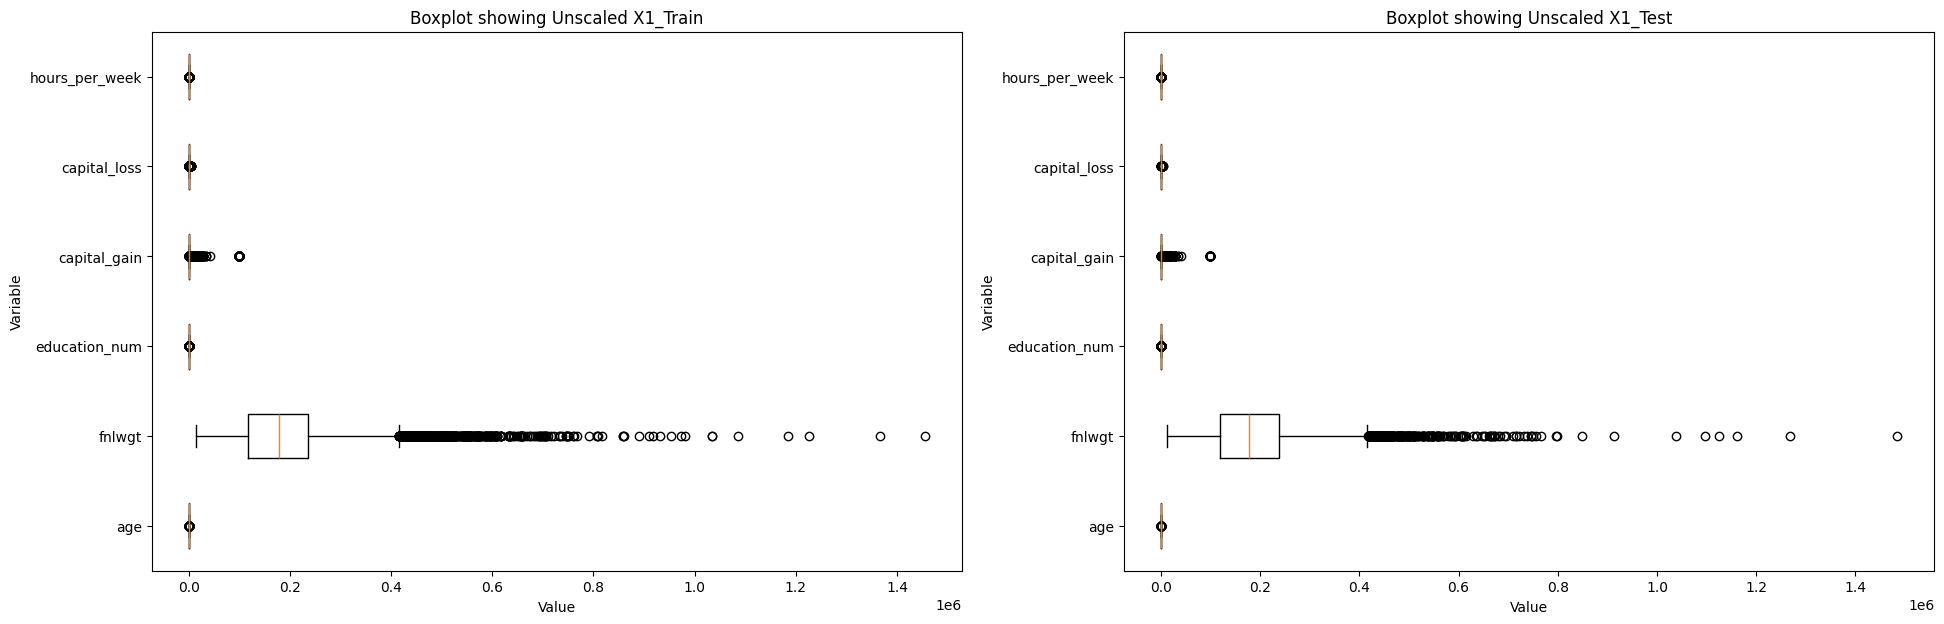

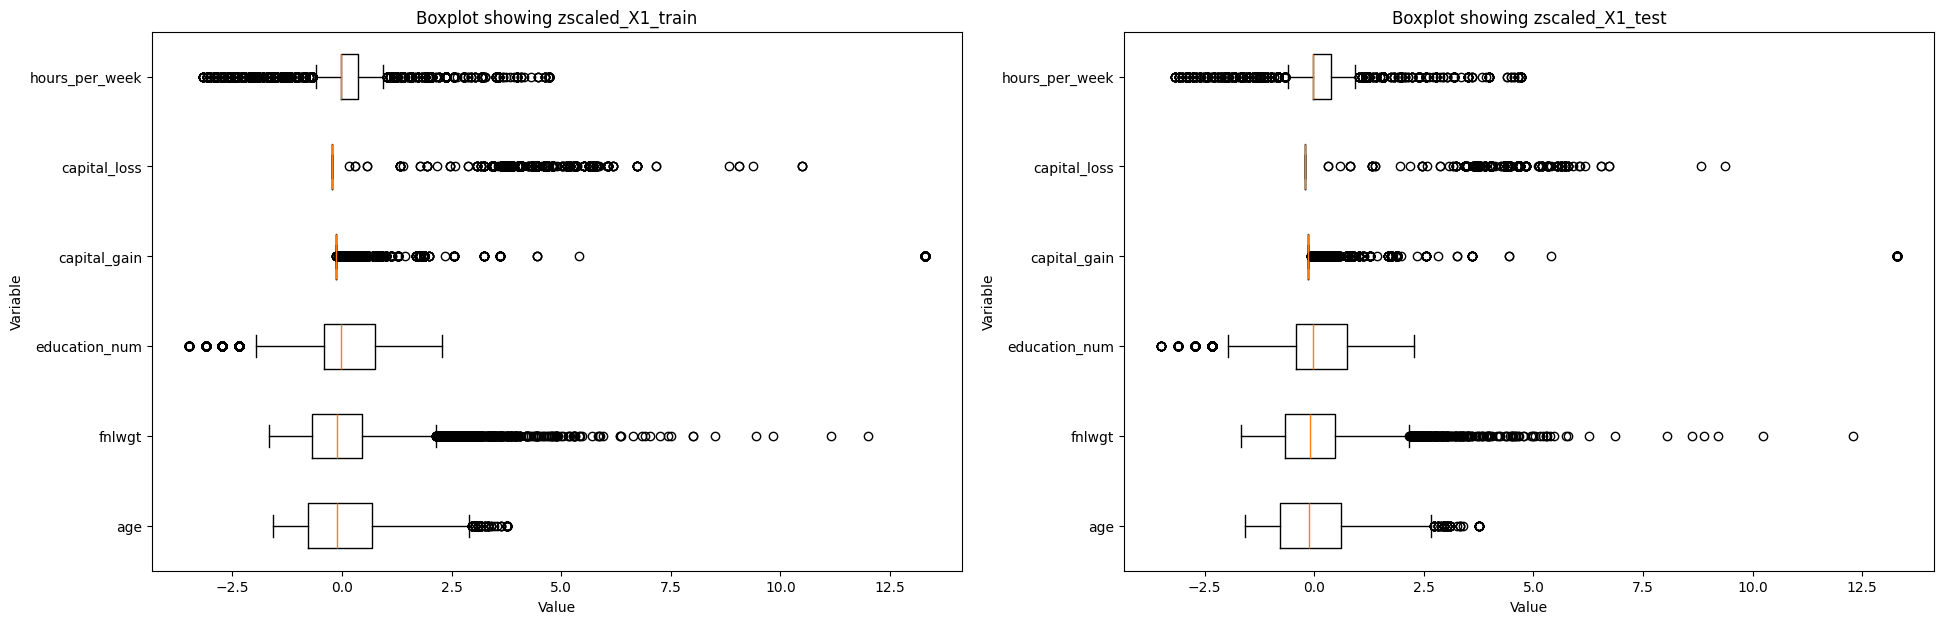

In [38]:
box_plot(encoded_X1_train, "Unscaled X1_Train",
        encoded_X1_test, "Unscaled X1_Test")
box_plot(zscaled_X1_train,"zscaled_X1_train",
         zscaled_X1_test,"zscaled_X1_test")

## 8.2. Robust Scaling

In [39]:
rscaler1 = RobustScaler()

rscaled_X1_train = encoded_X1_train.copy()
rscaled_X1_test = encoded_X1_test.copy()

rscaled_X1_train[numerical] = rscaler1.fit_transform(rscaled_X1_train[numerical])
rscaled_X1_test[numerical] = rscaler1.transform(rscaled_X1_test[numerical])

In [40]:
rscaled_X1_train.head(3)

,age,workclass_1,workclass_2,workclass_3,workclass_4,workclass_5,workclass_6,workclass_7,workclass_8,workclass_9,...,native_country_32,native_country_33,native_country_34,native_country_35,native_country_36,native_country_37,native_country_38,native_country_39,native_country_40,native_country_41
24027,2.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10781,1.05,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8676,-0.50,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


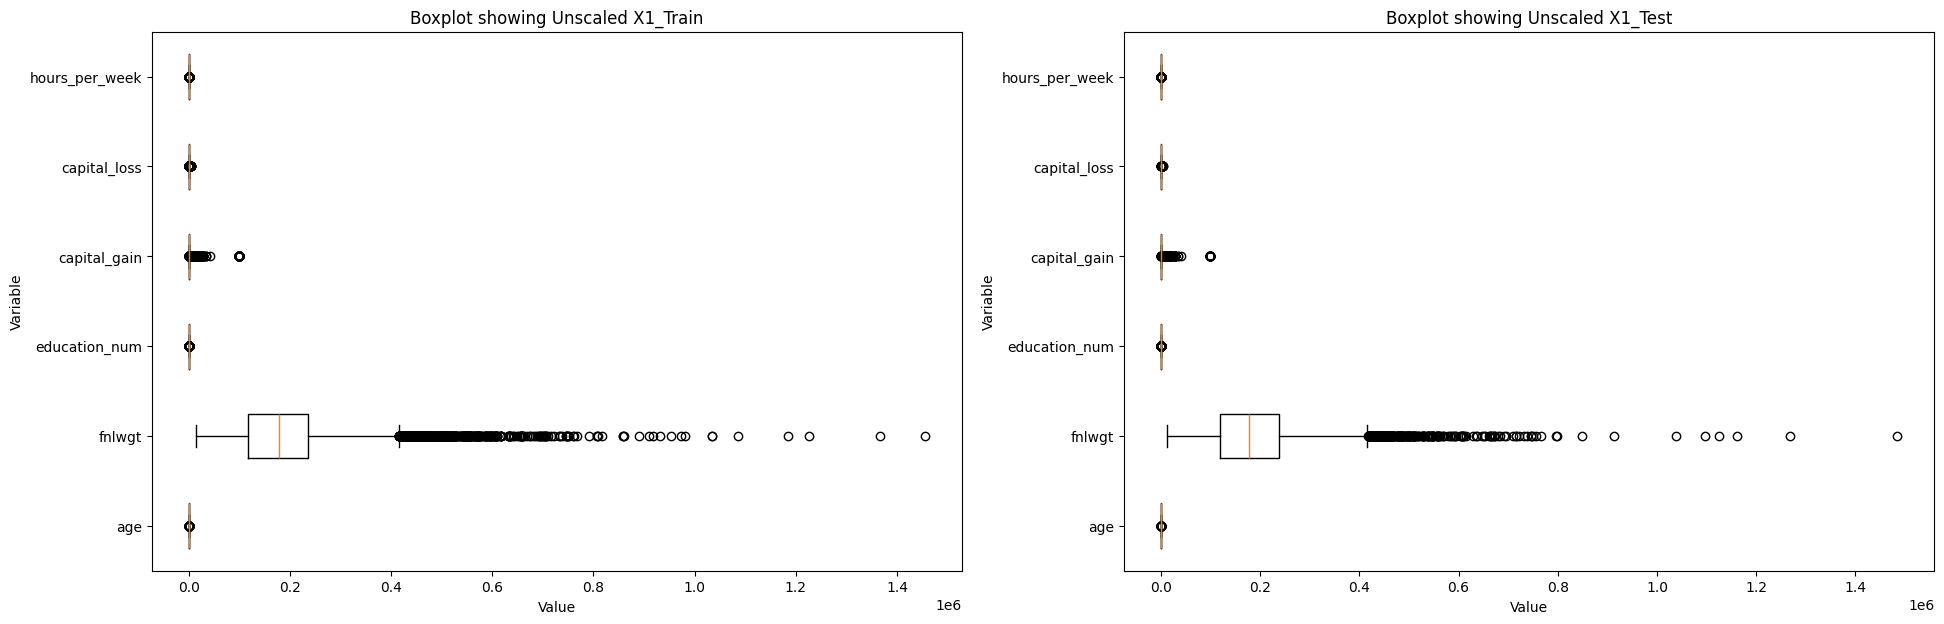

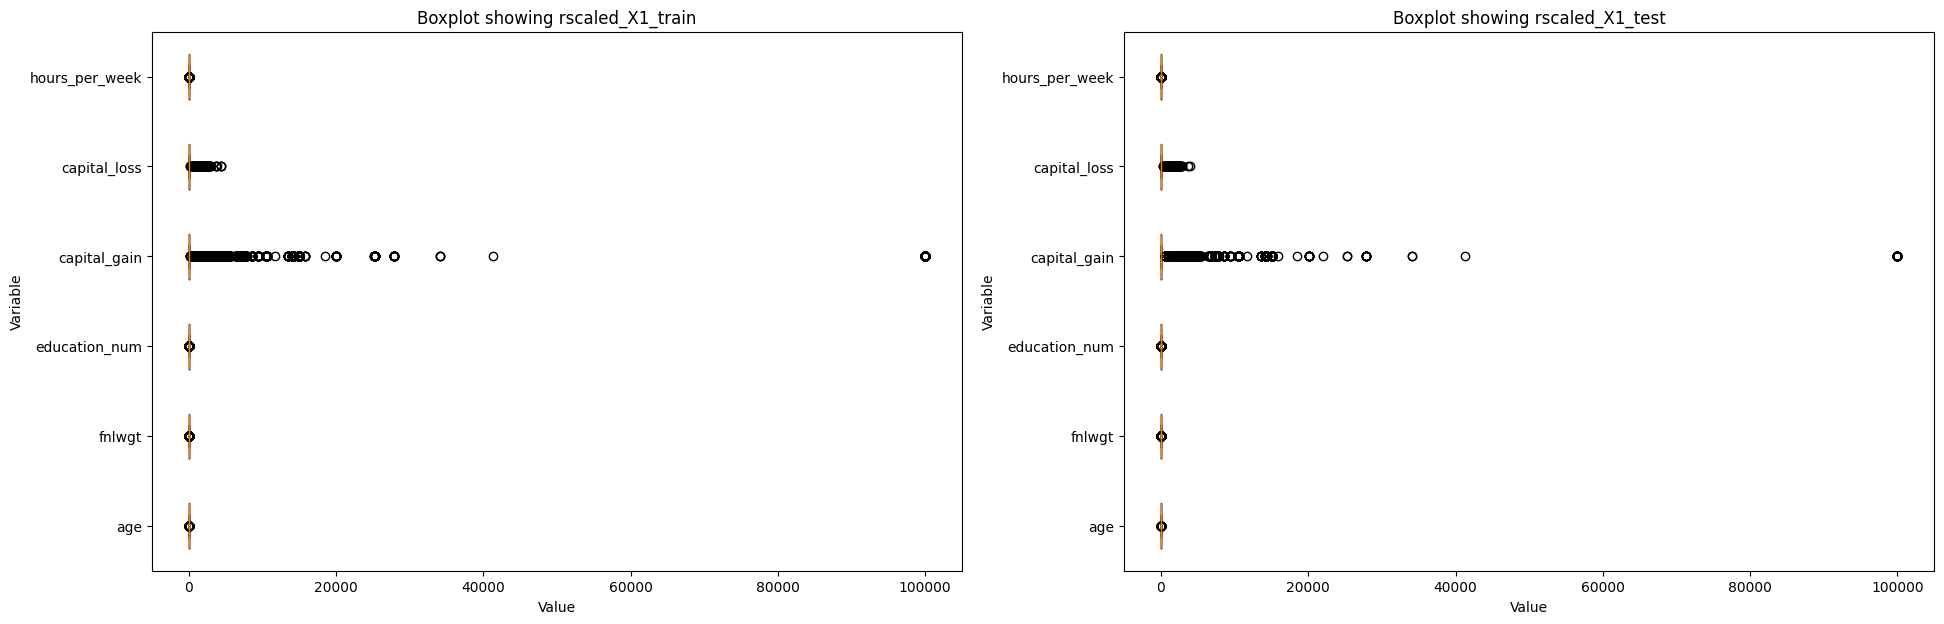

In [41]:
box_plot(encoded_X1_train, "Unscaled X1_Train",
        encoded_X1_test, "Unscaled X1_Test")
box_plot(rscaled_X1_train,"rscaled_X1_train",
         rscaled_X1_test,"rscaled_X1_test")

### 8.2.1. RobustScaler scales the data based on the interquartile range (IQR), which is robust to outliers but can result in a wider range of scaled values for points that are far from the median


X_scaled = (X - Q1(X)) / IQR(X)

where:
- X is the original data.
- X_scaled is the scaled data.
- Q1(X) is the first quartile of X.
- IQR(X) is the interquartile range of X, calculated as Q3(X) - Q1(X).

RobustScaler scales the data by subtracting the median (which makes it robust to outliers) and dividing by the IQR

### 8.2.2. After scaling with RobustScaler we see an increase i spread of capital-gain as the data points that were already far from the median (i.e., potential outliers). This is a characteristic of RobustScaler and is intended to maintain the relative distances between data points while accounting for outliers.

## 8.4. No Scaling

In [42]:
unscaled_X1_train = encoded_X1_train.copy()
unscaled_X1_test = encoded_X1_test.copy()

# 9. Model Training For "?" replaced by string "Unknown"

## 9.1. Naive Bayes

### 9.1.1. For Z-Score Scaled Values

#### 9.1.1.1. Holdout and K-fold cross validation for k=5

In [43]:
results_9111 = []

for k in kfold_values:
    kfold = KFold(n_splits=k, shuffle=True, random_state=10)
    nb = GaussianNB()
    cv_scores = cross_val_score(nb, zscaled_X1_train, y1_train.values.ravel(), cv=kfold)
    nb.fit(zscaled_X1_train, y1_train.values.ravel())
    y1_pred = nb.predict(zscaled_X1_test)
    test_score = accuracy_score(y1_test.values.ravel(), y1_pred)
    results_9111.append({
        'k': k,
        'cross_val_scores': cv_scores,
        'mean_cross_val_score': cv_scores.mean(),
        'test_score': test_score,
        'model': nb
    })
for result in results_9111:
    print(f"K-Fold: {result['k']}")
    print(f"Cross-validation scores: {result['cross_val_scores']}")
    print(f"Mean Cross-validation score: {result['mean_cross_val_score']}")
    print(f"Test set score: {result['test_score']}")
    print(f"Model: {result['model']}\n")

K-Fold: 5
Cross-validation scores: [0.54748848 0.5433209  0.58424748 0.51426064 0.5355419 ]
Mean Cross-validation score: 0.5449718819926274
Test set score: 0.5740608045859351
Model: GaussianNB()



#### 9.1.1.2. Holdout and stratified K-fold cross validation, k=5

In [44]:
results_9112 = []

for k in skf_values:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=10)
    nb = GaussianNB()
    cv_scores = cross_val_score(nb, zscaled_X1_train, y1_train.values.ravel(), cv=skf)
    nb.fit(zscaled_X1_train, y1_train.values.ravel())
    y1_pred = nb.predict(zscaled_X1_test)
    test_score = accuracy_score(y1_test.values.ravel(), y1_pred)
    results_9112.append({
        'skf': k,
        'cross_val_scores': cv_scores,
        'mean_cross_val_score': cv_scores.mean(),
        'test_score': test_score,
        'model': nb
    })

for result in results_9112:
    print(f"Stratified K-Fold: {result['skf']}")
    print(f"Cross-validation scores: {result['cross_val_scores']}")
    print(f"Mean Cross-validation score: {result['mean_cross_val_score']}")
    print(f"Test set score: {result['test_score']}")
    print(f"Model: {result['model']}\n")

Stratified K-Fold: 5
Cross-validation scores: [0.59113841 0.54792718 0.53927161 0.50833699 0.56186924]
Mean Cross-validation score: 0.549708685143284
Test set score: 0.5740608045859351
Model: GaussianNB()



### 9.1.2. For Robust Scaled Values

#### 9.1.2.1. Holdout and K-fold cross validation for k=5

In [45]:
results_9121 = []

for k in kfold_values:
    kfold = KFold(n_splits=k, shuffle=True, random_state=10)
    nb = GaussianNB()
    cv_scores = cross_val_score(nb, rscaled_X1_train, y1_train.values.ravel(), cv=kfold)
    nb.fit(rscaled_X1_train, y1_train.values.ravel())
    y1_pred = nb.predict(rscaled_X1_test)
    test_score = accuracy_score(y1_test.values.ravel(), y1_pred)
    results_9121.append({
        'k': k,
        'cross_val_scores': cv_scores,
        'mean_cross_val_score': cv_scores.mean(),
        'test_score': test_score,
        'model': nb
    })
for result in results_9121:
    print(f"K-Fold: {result['k']}")
    print(f"Cross-validation scores: {result['cross_val_scores']}")
    print(f"Mean Cross-validation score: {result['mean_cross_val_score']}")
    print(f"Test set score: {result['test_score']}")
    print(f"Model: {result['model']}\n")

K-Fold: 5
Cross-validation scores: [0.80280763 0.79403378 0.81526986 0.80210619 0.79574375]
Mean Cross-validation score: 0.8019922403943577
Test set score: 0.7959873067867745
Model: GaussianNB()



#### 9.1.2.2. Holdout and stratified K-fold cross validation=5

In [46]:
results_9122 = []

for k in skf_values:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=10)
    nb = GaussianNB()
    cv_scores = cross_val_score(nb, rscaled_X1_train, y1_train.values.ravel(), cv=skf)
    nb.fit(rscaled_X1_train, y1_train.values.ravel())
    y1_pred = nb.predict(rscaled_X1_test)
    test_score = accuracy_score(y1_test.values.ravel(), y1_pred)
    results_9122.append({
        'skf': k,
        'cross_val_scores': cv_scores,
        'mean_cross_val_score': cv_scores.mean(),
        'test_score': test_score,
        'model': nb
    })

for result in results_9122:
    print(f"Stratified K-Fold: {result['skf']}")
    print(f"Cross-validation scores: {result['cross_val_scores']}")
    print(f"Mean Cross-validation score: {result['mean_cross_val_score']}")
    print(f"Test set score: {result['test_score']}")
    print(f"Model: {result['model']}\n")


Stratified K-Fold: 5
Cross-validation scores: [0.80807195 0.80039482 0.79684072 0.79837648 0.81000439]
Mean Cross-validation score: 0.8027376714888537
Test set score: 0.7959873067867745
Model: GaussianNB()



### 9.1.3. For Non Scaled Values

#### 9.1.3.1. Holdout and K-fold cross validation for k=5

In [47]:
results_9131 = []

for k in kfold_values:
    kfold = KFold(n_splits=k, shuffle=True, random_state=10)
    nb = GaussianNB()
    cv_scores = cross_val_score(nb, unscaled_X1_train, y1_train.values.ravel(), cv=kfold)
    nb.fit(unscaled_X1_train, y1_train.values.ravel())
    y1_pred = nb.predict(unscaled_X1_test)
    test_score = accuracy_score(y1_test.values.ravel(), y1_pred)
    results_9131.append({
        'k': k,
        'cross_val_scores': cv_scores,
        'mean_cross_val_score': cv_scores.mean(),
        'test_score': test_score,
        'model': nb
    })

for result in results_9131:
    print(f"K-Fold: {result['k']}")
    print(f"Cross-validation scores: {result['cross_val_scores']}")
    print(f"Mean Cross-validation score: {result['mean_cross_val_score']}")
    print(f"Test set score: {result['test_score']}")
    print(f"Model: {result['model']}\n")

K-Fold: 5
Cross-validation scores: [0.79096293 0.79688528 0.79859588 0.79398859 0.80232558]
Mean Cross-validation score: 0.7965516521188097
Test set score: 0.7894359709284471
Model: GaussianNB()



#### 9.1.3.2. Navis Bayes with Holdout and stratified K-fold cross validation=5

In [48]:
results_9132 = []

for k in skf_values:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=10)
    nb = GaussianNB()
    cv_scores = cross_val_score(nb, unscaled_X1_train, y1_train.values.ravel(), cv=skf)
    nb.fit(unscaled_X1_train, y1_train.values.ravel())
    y1_pred = nb.predict(unscaled_X1_test)
    test_score = accuracy_score(y1_test.values.ravel(), y1_pred)
    results_9132.append({
        'skf': k,
        'cross_val_scores': cv_scores,
        'mean_cross_val_score': cv_scores.mean(),
        'test_score': test_score,
        'model': nb
    })

for result in results_9132:
    print(f"Stratified K-Fold: {result['skf']}")
    print(f"Cross-validation scores: {result['cross_val_scores']}")
    print(f"Mean Cross-validation score: {result['mean_cross_val_score']}")
    print(f"Test set score: {result['test_score']}")
    print(f"Model: {result['model']}\n")

Stratified K-Fold: 5
Cross-validation scores: [0.79578855 0.79403378 0.79969285 0.79398859 0.79859588]
Mean Cross-validation score: 0.7964199288139773
Test set score: 0.7894359709284471
Model: GaussianNB()



## 9.1 Naive Bayes Result : Robust Scaling With Stratified k-fold Sampling Has Given Best Accuracy = 79.59%

## 9.2. Decision Tree Classifier

In [62]:
dtc=DecisionTreeClassifier()

In [63]:
dtc.fit(rscaled_X1_train, y1_train.values.ravel())

DecisionTreeClassifier()

In [66]:
dtc_y1_pred=dtc.predict(rscaled_X1_test)

In [68]:
dtc.score(rscaled_X1_test,y1_test)

0.8118538233186611

In [69]:
dtc_cv_scores = cross_val_score(dtc, rscaled_X1_train, y1_train, cv=5)
dtc_cv_scores.mean()

0.8139260965464643

### Cross Validation doesn't show significant improvement

## 9.2 Decision Tree Classifier Result :  Accuracy 81.18% is slightly better than NB accuracy of 79.59%

# 10. Post-Processing

### Compare the train-set and test-set accuracy

We will also compare the train-set and test-set accuracy to check for overfitting.

In [75]:
print('Test-set accuracy score: {0:0.4f}'. format(accuracy_score(y1_test, dtc_y1_pred)))

Test-set accuracy score: 0.8119


The training-set accuracy score is 80.05% while the test-set accuracy to be 80.07%. These two values are quite comparable. So, there is no sign of overfitting. 


Based on the above analysis we can conclude that our classification model accuracy is good. Our model is doing great for **predicting the class labels**


But,
#### 1. It does not give the underlying distribution of values
#### 2. It does not tell anything about the type of errors our classifer is making

We have another tool called `Confusion matrix` that comes to our rescue.

## 15. Confusion matrix


A confusion matrix is a tool for summarizing the performance of a classification algorithm. A confusion matrix will give us a clear picture of classification model performance and the types of errors produced by the model. It gives us a summary of correct and incorrect predictions broken down by each category. The summary is represented in a tabular form.


Four types of outcomes are possible while evaluating a classification model performance. These four outcomes are described below:-


**True Positives (TP)** – True Positives occur when we predict an observation belongs to a certain class and the observation actually belongs to that class.


**True Negatives (TN)** – True Negatives occur when we predict an observation does not belong to a certain class and the observation actually does not belong to that class.


**False Positives (FP)** – False Positives occur when we predict an observation belongs to a    certain class but the observation actually does not belong to that class. This type of error is called **Type I error.**



**False Negatives (FN)** – False Negatives occur when we predict an observation does not belong to a certain class but the observation actually belongs to that class. This is a very serious error and it is called **Type II error.**



These four outcomes are summarized in a confusion matrix given below.


In [ ]:
# Print the Confusion Matrix and slice it into four pieces

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred2)

print('Confusion matrix\n\n', cm)

print('\nTrue Positives(TP) = ', cm[0,0])

print('\nTrue Negatives(TN) = ', cm[1,1])

print('\nFalse Positives(FP) = ', cm[0,1])

print('\nFalse Negatives(FN) = ', cm[1,0])

The confusion matrix shows `5914 + 1908 = 7822 correct predictions` and `1493 + 454 = 1947 incorrect predictions`.


In this case, we have

- `True Positives` (Actual Positive:1 and Predict Positive:1) - 5914


- `True Negatives` (Actual Negative:0 and Predict Negative:0) - 1908


- `False Positives` (Actual Negative:0 but Predict Positive:1) - 1493 `(Type I error)`


- `False Negatives` (Actual Positive:1 but Predict Negative:0) - 454 `(Type II error)`

## Heatmap

In [ ]:
# visualize confusion matrix with seaborn heatmap

cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'], 
                                 index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

## 16. Classification metrices

### Classification Report


**Classification report** is another way to evaluate the classification model performance. It displays the  **precision**, **recall**, **f1** and **support** scores for the model which have been described later.

We can print a classification report as follows:-

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred2))

### Classification accuracy

In [ ]:
TP = cm[0,0]
TN = cm[1,1]
FP = cm[0,1]
FN = cm[1,0]

In [ ]:
# print classification accuracy

classification_accuracy = (TP + TN) / float(TP + TN + FP + FN)

print('Classification accuracy : {0:0.4f}'.format(classification_accuracy))

### Classification error

In [ ]:
# print classification error

classification_error = (FP + FN) / float(TP + TN + FP + FN)

print('Classification error : {0:0.4f}'.format(classification_error))


### Precision


**Precision** can be defined as the percentage of correctly predicted positive outcomes out of all the predicted positive outcomes. It can be given as the ratio of true positives (TP) to the sum of true and false positives (TP + FP). 


So, **Precision** identifies the proportion of correctly predicted positive outcome. It is more concerned with the positive class than the negative class.



Mathematically, precision can be defined as the ratio of `TP to (TP + FP)`.



In [ ]:
# print precision score

precision = TP / float(TP + FP)

print('Precision : {0:0.4f}'.format(precision))

### Recall


Recall can be defined as the percentage of correctly predicted positive outcomes out of all the actual positive outcomes.
It can be given as the ratio of true positives (TP) to the sum of true positives and false negatives (TP + FN). **Recall** is also called **Sensitivity**.


**Recall** identifies the proportion of correctly predicted actual positives.


Mathematically, recall can be given as the ratio of `TP to (TP + FN)`.



In [ ]:
recall = TP / float(TP + FN)

print('Recall or Sensitivity : {0:0.4f}'.format(recall))

### True Positive Rate


**True Positive Rate** is synonymous with **Recall**.


In [ ]:
true_positive_rate = TP / float(TP + FN)

print('True Positive Rate : {0:0.4f}'.format(true_positive_rate))

### False Positive Rate

In [ ]:
false_positive_rate = FP / float(FP + TN)

print('False Positive Rate : {0:0.4f}'.format(false_positive_rate))

### Specificity

In [ ]:
specificity = TN / (TN + FP)

print('Specificity : {0:0.4f}'.format(specificity))

### f1-score


**f1-score** is the weighted harmonic mean of precision and recall. The best possible **f1-score** would be 1.0 and the worst 
would be 0.0.  **f1-score** is the harmonic mean of precision and recall. So, **f1-score** is always lower than accuracy measures as they embed precision and recall into their computation. The weighted average of `f1-score` should be used to 
compare classifier models, not global accuracy.




### Support


**Support** is the actual number of occurrences of the class in our dataset.

## 17. Calculate class probabilities

In [ ]:
# print the first 10 predicted probabilities of two classes- 0 and 1

y_pred_prob = gnb2.predict_proba(X_test_scaled2)[0:10]

y_pred_prob

### Observations


- In each row, the numbers sum to 1.


- There are 2 columns which correspond to 2 classes - `<=50K` and `>50K`.

    - Class 0 => <=50K - Class that a person makes less than equal to 50K.    
    
    - Class 1 => >50K  - Class that a person makes more than 50K. 
        
    
- Importance of predicted probabilities

    - We can rank the observations by probability of whether a person makes less than or equal to 50K or more than 50K.


- predict_proba process

    - Predicts the probabilities    
    
    - Choose the class with the highest probability    
    
    
- Classification threshold level

    - There is a classification threshold level of 0.5.    
    
    - Class 0 => <=50K - probability of salary less than or equal to 50K is predicted if probability < 0.5.    
    
    - Class 1 => >50K - probability of salary more than 50K is predicted if probability > 0.5.    
    


In [ ]:
# store the probabilities in dataframe

y_pred_prob_df = pd.DataFrame(data=y_pred_prob, columns=['Prob of - <=50K', 'Prob of - >50K'])

y_pred_prob_df

In [ ]:
# print the first 10 predicted probabilities for class 1 - Probability of >50K

gnb2.predict_proba(X_test_scaled2)[0:10, 1]

In [ ]:
# store the predicted probabilities for class 1 - Probability of >50K

y_pred2_1 = gnb2.predict_proba(X_test_scaled2)[:, 1]
y_pred2_1

### 18. Histogram of predicted probabilities

In [ ]:
# plot histogram with 10 bins
plt.hist(y_pred2_1, bins = 10)

# set the title of predicted probabilities
plt.title('Histogram of predicted probabilities of salaries >50K')

# set the x-axis limit
plt.xlim(0,1)

# set the title
plt.xlabel('Predicted probabilities of salaries >50K')
plt.ylabel('Frequency')

### Observations


- We can see that the above histogram is highly positive skewed.


- The first column tell us that there are approximately 5700 observations with probability between 0.0 and 0.1 whose salary 
  is <=50K.


- There are relatively small number of observations with probability > 0.5.


- So, these small number of observations predict that the salaries will be >50K.


- Majority of observations predcit that the salaries will be <=50K.

## 19. k-Fold Cross Validation

In [ ]:
# Applying 10-Fold Cross Validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(gnb2, X_train_scaled2, y_train, cv = 10, scoring='accuracy')

print('Cross-validation scores:{}'.format(scores))

We can summarize the cross-validation accuracy by calculating its mean.

In [ ]:
# compute Average cross-validation score

print('Average cross-validation score: {:.4f}'.format(scores.mean()))

### Interpretation


- Using the mean cross-validation, we can conclude that we expect the model to be around 80.11% accurate on average.

- If we look at all the 10 scores produced by the 10-fold cross-validation, we can also conclude that there is a relatively small variance in the accuracy between folds, ranging from 80.70% accuracy to 79.06% accuracy. So, we can conclude that the model is independent of the particular folds used for training.

- Our original model accuracy is 0.8007, the mean cross-validation accuracy is 0.8011. So, the 10-fold cross-validation accuracy does not result in a significant performance improvement for this model.

## 20. Results and conclusion


**1.	In this project, I build a Gaussian Naïve Bayes Classifier model to predict whether a person makes over 50K a year. The model yields a very good performance as indicated by the model accuracy which was found to be 0.8007\
2.	The training-set accuracy score is 0.8005 while the test-set accuracy to be 0.8007. These two values are quite comparable. So, there is no sign of overfitting.\
3.	Comparing the model accuracy score which is 0.8007 with null accuracy score which is 0.7582. So, we can conclude that our Gaussian Naïve Bayes classifier model is doing a very good job in predicting the class labels.\
4.	Using the mean cross-validation, we can conclude that we expect the model to be around 80.11% accurate on average.\
5.	If we look at all the 10 scores produced by the 10-fold cross-validation, we can also conclude that there is a relatively small variance in the accuracy between folds, ranging from 80.70% accuracy to 79.06% accuracy. So, we can conclude that the model is independent of the particular folds used for training.\
6.	Our original model accuracy is 0.8007, but the mean cross-validation accuracy is 0.8011. So, the 10-fold cross-validation accuracy does not result in a significant performance improvement for this model**

<a href="https://ibb.co/Mh9mdxx"><img src="https://i.ibb.co/6ZNkQ77/image.png" alt="image" border="0"></a>